# Ly6a–peptide molecular-dynamics feasibility validation

This notebook extends the receptor-aware structural triage performed in Notebook 04 with a preliminary molecular-dynamics layer. Two Ly6a–peptide complexes are followed in explicit-solvent GROMACS simulations to examine whether static ColabFold-derived rankings are complemented by dynamic information about peptide pose stability and receptor–peptide interface behaviour.

The comparison focuses on:

- **pep_006 — VYRPPRLFVRNH**, which received the higher Ly6a structure-aware reward in Notebook 04,
- **pep_000 — PVRPQQPRPLYYYH**, which received a lower ColabFold-derived reward but provides a useful contrasting trajectory.

This notebook performs the following steps:

1. define the two MD systems and analysis environment,
2. document the simulation setup and verify trajectory integrity,
3. quantify Ly6a backbone relaxation as a trajectory-level QC measure,
4. calculate receptor-fitted peptide RMSD,
5. measure retention of the initial receptor–peptide contact network,
6. quantify current heavy-atom interface contacts and normalize them by peptide size,
7. calculate minimum and centre-of-mass receptor–peptide distances,
8. quantify intermolecular hydrogen bonding,
9. summarize complementary late-window interface descriptors,
10. visualize receptor-aligned structural evolution,
11. compare the MD results with the preceding ColabFold-derived ranking.

Important scope note:

The simulations are used as a **computational feasibility and dynamic-triage layer**, not as evidence of binding affinity, BBB transport, transcytosis or therapeutic activity. The starting complexes originate from deliberately lightweight ColabFold screening, and the present simulations consist of one 10 ns trajectory per peptide.

The preliminary Ly6a construct also does not reproduce the complete native disulfide topology and is treated as an isolated extracellular-domain approximation rather than in its native membrane/GPI-anchored environment. The results should therefore be interpreted as conditional on the current starting structures.

In the wider prototype, this notebook adds a dynamic structural layer:

**omics-guided target prioritisation → peptide generation → ColabFold receptor-aware triage → molecular-dynamics feasibility analysis → reward-guided optimisation**

## 1. Define MD systems and analysis environment

The two systems were prepared and simulated independently using the same MD protocol. Analysis is performed on periodicity-corrected and centred production trajectories.

For both systems:

- force field: **AMBER99SB-ILDN**
- water model: **TIP3P**
- simulation temperature: **300 K**
- pressure: **1 bar**
- electrostatics: **PME**
- integration timestep: **2 fs**
- production duration: **10 ns**
- trajectory output interval: **5 ps**

The simulations were performed with **GROMACS 2026.3**. `pep_006` contains 12 residues and `pep_000` contains 14 residues.

In [1]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array, calc_bonds

# ============================================================
# Project and systems
# ============================================================

PROJECT = Path(
    "/home/bnaranjani/projects/"
    "2026-09-18-ly6a-peptide-md-validation"
)

SYSTEMS = {
    "pep_006": PROJECT / "high_score_pep006" / "07_production_md",
    "pep_000": PROJECT / "low_score_pep000" / "07_production_md",
}

SEQUENCES = {
    "pep_006": "VYRPPRLFVRNH",
    "pep_000": "PVRPQQPRPLYYYH",
}

GMX = "/home/bnaranjani/miniforge3/envs/gromacs-md/bin/gmx"

# Atom ordering after pdb2gmx
N_RECEPTOR = 1269

N_PROTEIN = {
    "pep_006": 1495,
    "pep_000": 1525,
}

for name, path in SYSTEMS.items():
    trajectory = path / "md_nojump_centered.xtc"
    topology = path / "md.tpr"

    print(
        f"{name}: {SEQUENCES[name]}\n"
        f"  topology   : {topology}\n"
        f"  trajectory : {trajectory}\n"
    )

pep_006: VYRPPRLFVRNH
  topology   : /home/bnaranjani/projects/2026-09-18-ly6a-peptide-md-validation/high_score_pep006/07_production_md/md.tpr
  trajectory : /home/bnaranjani/projects/2026-09-18-ly6a-peptide-md-validation/high_score_pep006/07_production_md/md_nojump_centered.xtc

pep_000: PVRPQQPRPLYYYH
  topology   : /home/bnaranjani/projects/2026-09-18-ly6a-peptide-md-validation/low_score_pep000/07_production_md/md.tpr
  trajectory : /home/bnaranjani/projects/2026-09-18-ly6a-peptide-md-validation/low_score_pep000/07_production_md/md_nojump_centered.xtc



## 2. Validate production trajectories

Before calculating structural descriptors, the production trajectories are checked for basic integrity and consistency.

For each system, the analysis confirms:

- successful loading of the GROMACS topology and processed production trajectory,
- a 10 ns trajectory duration,
- 5 ps frame spacing,
- 2,001 trajectory frames,
- consistent atom counts throughout the trajectory.

These checks ensure that subsequent comparisons use equivalent simulation windows and rule out trajectory truncation or frame-indexing artefacts.

In [2]:
# ============================================================
# 2. Validate production trajectories
# ============================================================

trajectory_qc = []

for name, path in SYSTEMS.items():

    topology = path / "npt.gro"
    trajectory = path / "md_nojump_centered.xtc"

    u = mda.Universe(
        str(topology),
        str(trajectory)
    )

    n_frames = len(u.trajectory)
    n_atoms = u.atoms.n_atoms
    dt_ps = float(u.trajectory.dt)

    u.trajectory[0]
    first_ps = float(u.trajectory.time)

    u.trajectory[-1]
    last_ps = float(u.trajectory.time)

    trajectory_qc.append({
        "system": name,
        "atoms": n_atoms,
        "frames": n_frames,
        "frame_spacing_ps": dt_ps,
        "start_ns": first_ps / 1000.0,
        "end_ns": last_ps / 1000.0,
    })

trajectory_qc = pd.DataFrame(trajectory_qc)

display(trajectory_qc)

assert (trajectory_qc["frames"] == 2001).all()
assert np.allclose(trajectory_qc["frame_spacing_ps"], 5.0)
assert np.allclose(trajectory_qc["start_ns"], 0.0)
assert np.allclose(trajectory_qc["end_ns"], 10.0)

print("Trajectory QC passed for both systems.")

,system,atoms,frames,frame_spacing_ps,start_ns,end_ns
0,pep_006,35858,2001,5.0,0.0,10.0
1,pep_000,39477,2001,5.0,0.0,10.0


Trajectory QC passed for both systems.


## 3. Define receptor and peptide analysis groups

The solvated systems preserve the same protein atom ordering after `pdb2gmx`:

- **Ly6a:** atoms 1–1269
- **pep_006:** atoms 1270–1495
- **pep_000:** atoms 1270–1525

Separate Ly6a and peptide backbone groups are generated for structural fitting and RMSD analysis. Full receptor and peptide groups are retained for interface, distance and hydrogen-bond analyses.

In [3]:
# ============================================================
# 3. Define receptor and peptide analysis groups
# ============================================================

for name, path in SYSTEMS.items():

    ndx = path / "analysis.ndx"

    result = subprocess.run(
        [
            GMX, "make_ndx",
            "-f", str(path / "md.tpr"),
            "-n", str(ndx),
            "-o", str(ndx),
        ],
        input=(
            "4 & 17\n"
            "name 19 Ly6a_Backbone\n"
            "4 & 18\n"
            "name 20 Peptide_Backbone\n"
            "q\n"
        ),
        text=True,
        capture_output=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"Index generation failed for {name}:\n{result.stderr[-2000:]}"
        )

    print(f"{name}: analysis groups ready")

pep_006: analysis groups ready
pep_000: analysis groups ready


## 4. Ly6a backbone relaxation as trajectory QC

Ly6a backbone RMSD is calculated after least-squares fitting of the Ly6a backbone to its starting structure.

This metric is used primarily as a **trajectory-level quality-control descriptor**, rather than as a peptide-ranking metric. Because the starting receptor models originate from preliminary ColabFold complexes and do not reproduce the complete native Ly6a disulfide topology, substantial receptor relaxation is expected and should be considered when interpreting peptide motion.

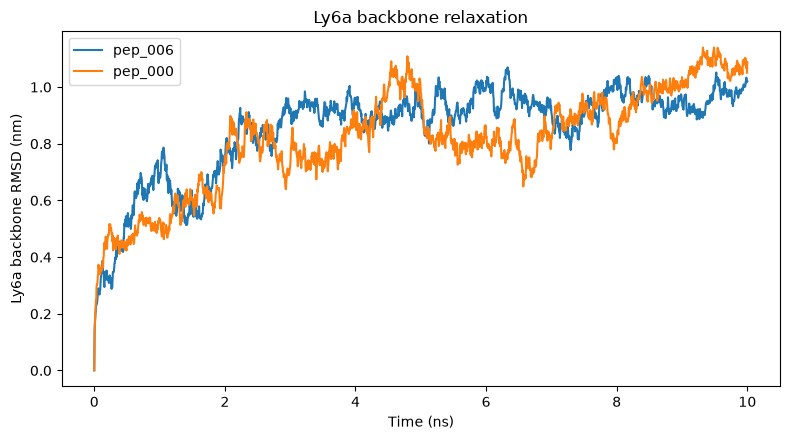

pep_006: 0–5 ns = 0.759 ± 0.189 nm | 5–10 ns = 0.944 ± 0.052 nm | late slope = 0.0077 nm/ns
pep_000: 0–5 ns = 0.716 ± 0.186 nm | 5–10 ns = 0.908 ± 0.113 nm | late slope = 0.0672 nm/ns


In [4]:
# ============================================================
# 4. Ly6a backbone RMSD
# ============================================================

ly6a_rmsd = {}

for name, path in SYSTEMS.items():

    outfile = path / "ly6a_backbone_rmsd.xvg"

    result = subprocess.run(
        [
            GMX, "rms",
            "-s", str(path / "md.tpr"),
            "-f", str(path / "md_nojump_centered.xtc"),
            "-n", str(path / "analysis.ndx"),
            "-o", str(outfile),
            "-tu", "ns",
        ],
        input="19\n19\n",
        text=True,
        capture_output=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"RMSD calculation failed for {name}:\n{result.stderr[-2000:]}"
        )

    ly6a_rmsd[name] = np.loadtxt(
        outfile,
        comments=("@", "#")
    )

# Plot
plt.figure(figsize=(8, 4.5))

for name, data in ly6a_rmsd.items():
    plt.plot(data[:, 0], data[:, 1], label=name)

plt.xlabel("Time (ns)")
plt.ylabel("Ly6a backbone RMSD (nm)")
plt.title("Ly6a backbone relaxation")
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
for name, data in ly6a_rmsd.items():

    time = data[:, 0]
    values = data[:, 1]

    early = values[(time >= 0) & (time < 5)]

    late_mask = (time >= 5) & (time <= 10)
    late = values[late_mask]

    slope = np.polyfit(time[late_mask], late, 1)[0]

    print(
        f"{name}: "
        f"0–5 ns = {early.mean():.3f} ± {early.std():.3f} nm | "
        f"5–10 ns = {late.mean():.3f} ± {late.std():.3f} nm | "
        f"late slope = {slope:.4f} nm/ns"
    )

## 5. Receptor-fitted peptide pose stability

To isolate peptide motion relative to Ly6a from overall translation and rotation of the complex, each trajectory is first fitted using the **Ly6a backbone** and RMSD is then calculated for the **peptide backbone**.

This provides a dynamic measure of how closely each peptide preserves its initial ColabFold-derived receptor-relative pose. Lower RMSD indicates greater preservation of the starting pose, but is not interpreted as stronger binding affinity.

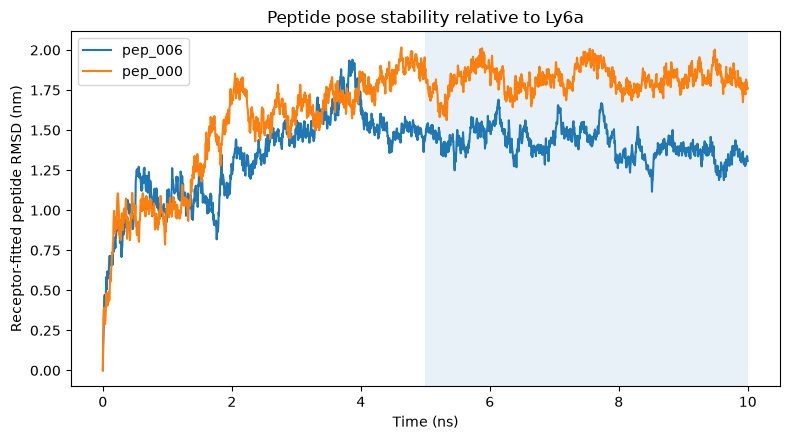

pep_006: 5–10 ns = 1.416 ± 0.092 nm | late slope = -0.0322 nm/ns
pep_000: 5–10 ns = 1.817 ± 0.076 nm | late slope = 0.0071 nm/ns


In [5]:
# ============================================================
# 5. Receptor-fitted peptide RMSD
# ============================================================

peptide_rmsd = {}

for name, path in SYSTEMS.items():

    outfile = path / "peptide_receptor_fitted_rmsd.xvg"

    result = subprocess.run(
        [
            GMX, "rms",
            "-s", str(path / "md.tpr"),
            "-f", str(path / "md_nojump_centered.xtc"),
            "-n", str(path / "analysis.ndx"),
            "-o", str(outfile),
            "-tu", "ns",
        ],
        input="19\n20\n",   # fit Ly6a backbone; measure peptide backbone
        text=True,
        capture_output=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"Peptide RMSD calculation failed for {name}:\n"
            f"{result.stderr[-2000:]}"
        )

    peptide_rmsd[name] = np.loadtxt(
        outfile,
        comments=("@", "#")
    )

# Plot
plt.figure(figsize=(8, 4.5))

for name, data in peptide_rmsd.items():
    plt.plot(data[:, 0], data[:, 1], label=name)

plt.axvspan(5, 10, alpha=0.10)

plt.xlabel("Time (ns)")
plt.ylabel("Receptor-fitted peptide RMSD (nm)")
plt.title("Peptide pose stability relative to Ly6a")
plt.legend()
plt.tight_layout()
plt.show()

# Late-window statistics
for name, data in peptide_rmsd.items():

    time = data[:, 0]
    values = data[:, 1]

    late_mask = (time >= 5) & (time <= 10)
    late_time = time[late_mask]
    late_values = values[late_mask]

    slope = np.polyfit(late_time, late_values, 1)[0]

    print(
        f"{name}: "
        f"5–10 ns = {late_values.mean():.3f} ± "
        f"{late_values.std():.3f} nm | "
        f"late slope = {slope:.4f} nm/ns"
    )

## 6. Retention of the initial receptor–peptide contact network

Heavy-atom receptor–peptide contacts present in the production starting structure are identified using a **4.5 Å cutoff**. The fraction of these exact starting contacts that remains present in each trajectory frame is then calculated.

This descriptor answers a different question from receptor-fitted peptide RMSD: it measures preservation of the **initial contact set**, not overall peptide pose similarity.

pep_006: 68 initial heavy-atom contacts
pep_000: 15 initial heavy-atom contacts


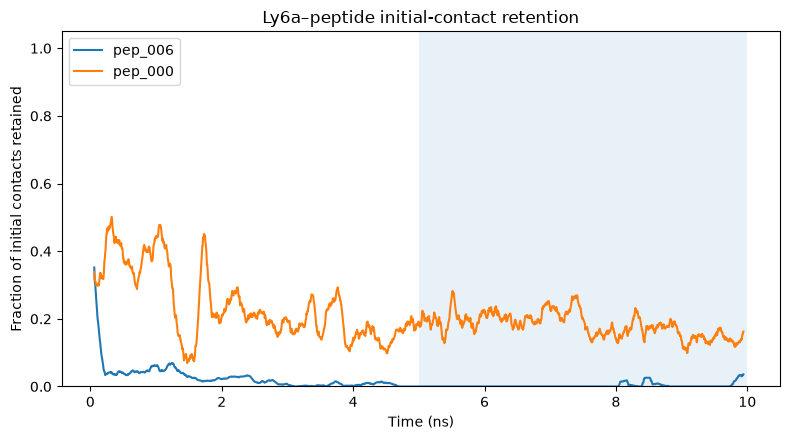

pep_006: 5–10 ns contact retention = 0.003 ± 0.013
pep_000: 5–10 ns contact retention = 0.182 ± 0.093


In [6]:
# ============================================================
# 6. Initial-contact retention
# ============================================================

contact_retention = {}

for name, path in SYSTEMS.items():

    # Exact production starting structure
    ref = mda.Universe(str(path / "npt.gro"))

    # Production trajectory
    u = mda.Universe(
        str(path / "npt.gro"),
        str(path / "md_nojump_centered.xtc")
    )

    ref_rec = ref.atoms[:N_RECEPTOR].select_atoms("not name H*")
    ref_pep = ref.atoms[N_RECEPTOR:N_PROTEIN[name]].select_atoms("not name H*")

    rec = u.atoms[:N_RECEPTOR].select_atoms("not name H*")
    pep = u.atoms[N_RECEPTOR:N_PROTEIN[name]].select_atoms("not name H*")

    # Contacts present at production start
    d0 = distance_array(
        ref_rec.positions,
        ref_pep.positions,
        box=ref.dimensions
    )

    rec_idx, pep_idx = np.where(d0 <= 4.5)  # Å

    times = []
    fractions = []

    for ts in u.trajectory:

        d = calc_bonds(
            rec.positions[rec_idx],
            pep.positions[pep_idx],
            box=u.dimensions
        )

        times.append(ts.time / 1000.0)
        fractions.append(np.mean(d <= 4.5))

    contact_retention[name] = np.column_stack(
        [times, fractions]
    )

    print(
        f"{name}: {len(rec_idx)} initial heavy-atom contacts"
    )

# Plot rolling mean for readability
plt.figure(figsize=(8, 4.5))

for name, data in contact_retention.items():
    smooth = pd.Series(data[:, 1]).rolling(
        25, center=True
    ).mean()

    plt.plot(
        data[:, 0],
        smooth,
        label=name
    )

plt.axvspan(5, 10, alpha=0.10)

plt.xlabel("Time (ns)")
plt.ylabel("Fraction of initial contacts retained")
plt.title("Ly6a–peptide initial-contact retention")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Late-window statistics
for name, data in contact_retention.items():

    mask = (
        (data[:, 0] >= 5) &
        (data[:, 0] <= 10)
    )

    vals = data[mask, 1]

    print(
        f"{name}: 5–10 ns contact retention = "
        f"{vals.mean():.3f} ± {vals.std():.3f}"
    )

## 7. Current receptor–peptide interface contacts

All receptor–peptide heavy-atom contacts within **4.5 Å** are counted for every trajectory frame.

Because the peptides differ in size, raw contact counts are complemented by a normalized descriptor:

**normalized interface contacts = total receptor–peptide heavy-atom contacts / peptide heavy-atom count**

This provides a simple measure of interface density and should be interpreted as a structural descriptor rather than a binding-affinity estimate.

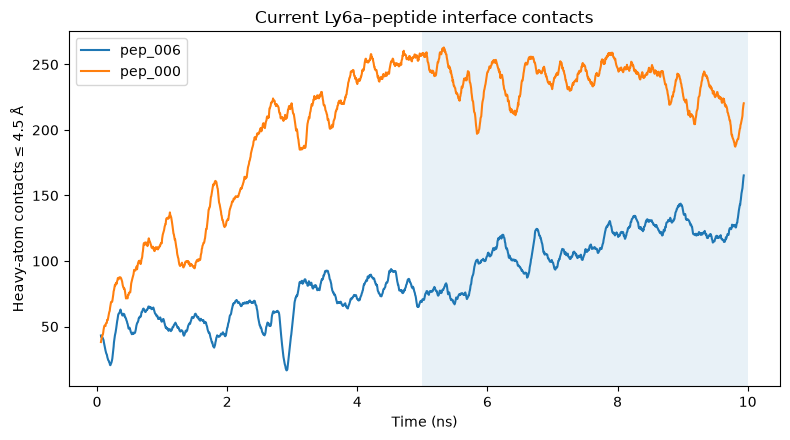

pep_006: contacts = 110.5 ± 24.3 | 111 peptide heavy atoms | normalized = 0.995 ± 0.219
pep_000: contacts = 236.2 ± 24.8 | 130 peptide heavy atoms | normalized = 1.817 ± 0.191


In [7]:
# ============================================================
# 7. Current interface contacts
# ============================================================

total_contacts = {}

for name, path in SYSTEMS.items():

    u = mda.Universe(
        str(path / "npt.gro"),
        str(path / "md_nojump_centered.xtc")
    )

    rec = u.atoms[:N_RECEPTOR].select_atoms("not name H*")
    pep = u.atoms[N_RECEPTOR:N_PROTEIN[name]].select_atoms("not name H*")

    times = []
    counts = []

    for ts in u.trajectory:

        d = distance_array(
            rec.positions,
            pep.positions,
            box=u.dimensions
        )

        times.append(ts.time / 1000.0)
        counts.append(np.sum(d <= 4.5))

    total_contacts[name] = np.column_stack(
        [times, counts]
    )

# Plot rolling mean
plt.figure(figsize=(8, 4.5))

for name, data in total_contacts.items():

    smooth = pd.Series(data[:, 1]).rolling(
        25, center=True
    ).mean()

    plt.plot(
        data[:, 0],
        smooth,
        label=name
    )

plt.axvspan(5, 10, alpha=0.10)

plt.xlabel("Time (ns)")
plt.ylabel("Heavy-atom contacts ≤ 4.5 Å")
plt.title("Current Ly6a–peptide interface contacts")
plt.legend()
plt.tight_layout()
plt.show()

# Raw and normalized late-window statistics
for name, path in SYSTEMS.items():

    data = total_contacts[name]

    mask = (
        (data[:, 0] >= 5) &
        (data[:, 0] <= 10)
    )

    raw = data[mask, 1]

    u = mda.Universe(str(path / "npt.gro"))

    pep = u.atoms[
        N_RECEPTOR:N_PROTEIN[name]
    ].select_atoms("not name H*")

    n_heavy = len(pep)

    normalized = raw / n_heavy

    print(
        f"{name}: "
        f"contacts = {raw.mean():.1f} ± {raw.std():.1f} | "
        f"{n_heavy} peptide heavy atoms | "
        f"normalized = "
        f"{normalized.mean():.3f} ± {normalized.std():.3f}"
    )

## 8. Receptor–peptide separation

Two complementary separation descriptors are calculated:

- **minimum heavy-atom distance**, representing the closest instantaneous receptor–peptide approach,
- **centre-of-mass (COM) distance**, representing the overall spatial separation between Ly6a and the peptide.

The minimum-distance metric mainly confirms continued close atomic contact, whereas COM distance is more informative for distinguishing the overall receptor–peptide association in these trajectories.

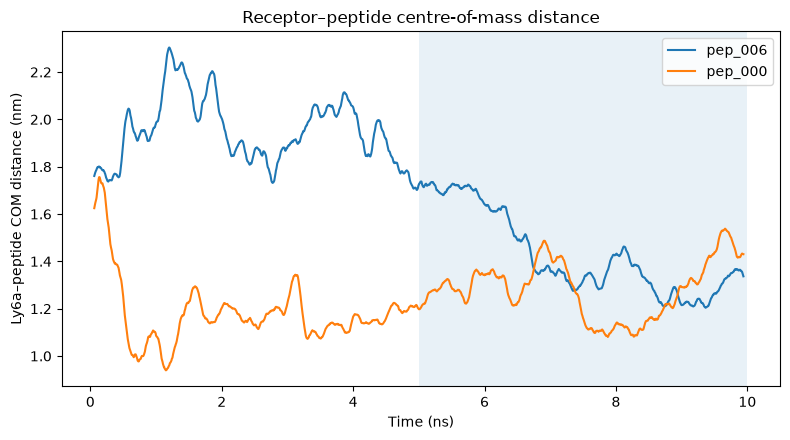

pep_006: min distance = 0.274 ± 0.008 nm | COM distance = 1.430 ± 0.177 nm
pep_000: min distance = 0.276 ± 0.007 nm | COM distance = 1.283 ± 0.125 nm


In [8]:
# ============================================================
# 8. Receptor–peptide separation
# ============================================================

interface_distance = {}

for name, path in SYSTEMS.items():

    u = mda.Universe(
        str(path / "npt.gro"),
        str(path / "md_nojump_centered.xtc")
    )

    rec = u.atoms[:N_RECEPTOR].select_atoms("not name H*")
    pep = u.atoms[N_RECEPTOR:N_PROTEIN[name]].select_atoms("not name H*")

    times = []
    min_dist = []
    com_dist = []

    for ts in u.trajectory:

        d = distance_array(
            rec.positions,
            pep.positions,
            box=u.dimensions
        )

        times.append(ts.time / 1000.0)

        # MDAnalysis distances are in Å
        min_dist.append(d.min() / 10.0)

        rec_com = rec.center_of_mass()
        pep_com = pep.center_of_mass()

        com_dist.append(
            np.linalg.norm(rec_com - pep_com) / 10.0
        )

    interface_distance[name] = np.column_stack(
        [times, min_dist, com_dist]
    )

# Plot COM distance
plt.figure(figsize=(8, 4.5))

for name, data in interface_distance.items():

    smooth = pd.Series(data[:, 2]).rolling(
        25, center=True
    ).mean()

    plt.plot(
        data[:, 0],
        smooth,
        label=name
    )

plt.axvspan(5, 10, alpha=0.10)

plt.xlabel("Time (ns)")
plt.ylabel("Ly6a–peptide COM distance (nm)")
plt.title("Receptor–peptide centre-of-mass distance")
plt.legend()
plt.tight_layout()
plt.show()

# Late-window statistics
for name, data in interface_distance.items():

    mask = (
        (data[:, 0] >= 5) &
        (data[:, 0] <= 10)
    )

    min_d = data[mask, 1]
    com_d = data[mask, 2]

    print(
        f"{name}: "
        f"min distance = {min_d.mean():.3f} ± {min_d.std():.3f} nm | "
        f"COM distance = {com_d.mean():.3f} ± {com_d.std():.3f} nm"
    )

## 9. Intermolecular hydrogen bonding

Intermolecular hydrogen bonds between Ly6a and each peptide are quantified using the GROMACS hydrogen-bond analysis.

Raw hydrogen-bond counts are complemented by normalization to peptide heavy-atom count to account for the different peptide sizes.

This metric is used as a supporting descriptor only. In the present trajectories, normalized hydrogen bonding is very similar between the two peptides and therefore does not strongly discriminate between them.

In [9]:
# ============================================================
# 9. Intermolecular hydrogen bonding
# ============================================================

hbonds = {}

for name, path in SYSTEMS.items():

    outfile = path / "intermolecular_hbonds.xvg"

    result = subprocess.run(
        [
            GMX, "hbond",
            "-s", str(path / "md.tpr"),
            "-f", str(path / "md_nojump_centered.xtc"),
            "-n", str(path / "analysis.ndx"),
            "-num", str(outfile),
        ],
        input="17\n18\n",   # Ly6a vs peptide
        text=True,
        capture_output=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"H-bond analysis failed for {name}:\n"
            f"{result.stderr[-2000:]}"
        )

    hbonds[name] = np.loadtxt(
        outfile,
        comments=("@", "#")
    )

# Late-window statistics
for name, data in hbonds.items():

    time_ns = data[:, 0] / 1000.0

    mask = (
        (time_ns >= 5) &
        (time_ns <= 10)
    )

    values = data[mask, 1]

    u = mda.Universe(
        str(SYSTEMS[name] / "npt.gro")
    )

    pep = u.atoms[
        N_RECEPTOR:N_PROTEIN[name]
    ].select_atoms("not name H*")

    n_heavy = len(pep)

    mean_hb = values.mean()
    sd_hb = values.std()
    normalized = mean_hb / n_heavy

    print(
        f"{name}: "
        f"H-bonds = {mean_hb:.2f} ± {sd_hb:.2f} | "
        f"normalized = {normalized:.4f} "
        f"H-bonds / peptide heavy atom"
    )

pep_006: H-bonds = 4.27 ± 1.53 | normalized = 0.0385 H-bonds / peptide heavy atom
pep_000: H-bonds = 5.19 ± 1.18 | normalized = 0.0399 H-bonds / peptide heavy atom


## 10. Integrated late-window comparison

For a compact comparison, the principal MD descriptors are summarized over the **5–10 ns** trajectory window.

Values are reported as **mean ± temporal standard deviation** within each trajectory. Because consecutive MD frames are temporally correlated, these values describe within-trajectory behaviour and **must not be interpreted as independent biological or statistical replicates**.

The descriptors intentionally capture different aspects of receptor–peptide behaviour:

- Ly6a backbone RMSD: receptor relaxation / trajectory QC,
- receptor-fitted peptide RMSD: preservation of the initial receptor-relative peptide pose,
- initial-contact retention: preservation of the exact starting contact network,
- normalized interface contacts: receptor–peptide interface density,
- minimum heavy-atom distance: persistence of close atomic contact,
- COM distance: overall receptor–peptide separation,
- normalized hydrogen bonding: intermolecular hydrogen-bond density.

In [10]:
# ============================================================
# 10. Integrated 5–10 ns summary
# ============================================================

def late_window(data, value_col, time_scale=1.0):
    """
    Extract values from the 5–10 ns comparison window.

    time_scale:
        1.0    -> time already in ns
        0.001  -> time stored in ps
    """
    time_ns = data[:, 0] * time_scale
    mask = (time_ns >= 5.0) & (time_ns <= 10.0)

    return data[mask, value_col]


summary_rows = []

for name in ["pep_006", "pep_000"]:

    # --------------------------------------------------------
    # Peptide heavy-atom count
    # --------------------------------------------------------
    u = mda.Universe(str(SYSTEMS[name] / "npt.gro"))

    pep = u.atoms[
        N_RECEPTOR:N_PROTEIN[name]
    ].select_atoms("not name H*")

    n_heavy = len(pep)

    # --------------------------------------------------------
    # Extract late-window values
    # --------------------------------------------------------
    ly6a_vals = late_window(
        ly6a_rmsd[name],
        value_col=1
    )

    peptide_rmsd_vals = late_window(
        peptide_rmsd[name],
        value_col=1
    )

    retention_vals = late_window(
        contact_retention[name],
        value_col=1
    )

    contact_vals = late_window(
        total_contacts[name],
        value_col=1
    )

    normalized_contact_vals = (
        contact_vals / n_heavy
    )

    min_distance_vals = late_window(
        interface_distance[name],
        value_col=1
    )

    com_distance_vals = late_window(
        interface_distance[name],
        value_col=2
    )

    # GROMACS hbond XVG time is in ps here
    hbond_vals = late_window(
        hbonds[name],
        value_col=1,
        time_scale=0.001
    )

    normalized_hbond_vals = (
        hbond_vals / n_heavy
    )

    # --------------------------------------------------------
    # Store descriptors
    # --------------------------------------------------------
    metrics = {
        "Ly6a backbone RMSD": (
            ly6a_vals,
            "nm"
        ),
        "Receptor-fitted peptide RMSD": (
            peptide_rmsd_vals,
            "nm"
        ),
        "Initial-contact retention": (
            retention_vals,
            "fraction"
        ),
        "Raw interface contacts": (
            contact_vals,
            "contacts"
        ),
        "Normalized interface contacts": (
            normalized_contact_vals,
            "contacts / peptide heavy atom"
        ),
        "Minimum heavy-atom distance": (
            min_distance_vals,
            "nm"
        ),
        "Receptor–peptide COM distance": (
            com_distance_vals,
            "nm"
        ),
        "Intermolecular H-bonds": (
            hbond_vals,
            "H-bonds"
        ),
        "Normalized intermolecular H-bonds": (
            normalized_hbond_vals,
            "H-bonds / peptide heavy atom"
        ),
    }

    for metric, (values, unit) in metrics.items():

        summary_rows.append({
            "system": name,
            "metric": metric,
            "unit": unit,
            "mean": values.mean(),
            "temporal_sd": values.std(),
        })


# ============================================================
# Numeric table for downstream plotting
# ============================================================

summary_numeric = pd.DataFrame(summary_rows)

metric_order = [
    "Ly6a backbone RMSD",
    "Receptor-fitted peptide RMSD",
    "Initial-contact retention",
    "Raw interface contacts",
    "Normalized interface contacts",
    "Minimum heavy-atom distance",
    "Receptor–peptide COM distance",
    "Intermolecular H-bonds",
    "Normalized intermolecular H-bonds",
]

summary_numeric["metric"] = pd.Categorical(
    summary_numeric["metric"],
    categories=metric_order,
    ordered=True,
)

summary_numeric = (
    summary_numeric
    .sort_values(["metric", "system"])
    .reset_index(drop=True)
)


# ============================================================
# Clean human-readable table
# ============================================================

formatted_rows = []

for metric in metric_order:

    subset = summary_numeric[
        summary_numeric["metric"] == metric
    ]

    unit = subset["unit"].iloc[0]

    row = {
        "Metric": metric,
        "Unit": unit,
    }

    for name in ["pep_006", "pep_000"]:

        values = subset[
            subset["system"] == name
        ].iloc[0]

        mean = values["mean"]
        sd = values["temporal_sd"]

        if metric in [
            "Raw interface contacts",
            "Intermolecular H-bonds",
        ]:
            row[name] = f"{mean:.2f} ± {sd:.2f}"

        elif metric in [
            "Normalized intermolecular H-bonds",
        ]:
            row[name] = f"{mean:.4f} ± {sd:.4f}"

        else:
            row[name] = f"{mean:.3f} ± {sd:.3f}"

    formatted_rows.append(row)


summary_table = pd.DataFrame(formatted_rows)

display(summary_table)

,Metric,Unit,pep_006,pep_000
0,Ly6a backbone RMSD,nm,0.944 ± 0.052,0.908 ± 0.113
1,Receptor-fitted peptide RMSD,nm,1.416 ± 0.092,1.817 ± 0.076
2,Initial-contact retention,fraction,0.003 ± 0.013,0.182 ± 0.093
3,Raw interface contacts,contacts,110.46 ± 24.31,236.22 ± 24.78
4,Normalized interface contacts,contacts / peptide heavy atom,0.995 ± 0.219,1.817 ± 0.191
5,Minimum heavy-atom distance,nm,0.274 ± 0.008,0.276 ± 0.007
6,Receptor–peptide COM distance,nm,1.430 ± 0.177,1.283 ± 0.125
7,Intermolecular H-bonds,H-bonds,4.27 ± 1.53,5.19 ± 1.18
8,Normalized intermolecular H-bonds,H-bonds / peptide heavy atom,0.0385 ± 0.0138,0.0399 ± 0.0091


## 11. Receptor-aligned structural evolution

To complement the quantitative trajectory descriptors, representative receptor–peptide structures were visualized at approximately **0, 3.3, 6.7 and 10 ns**.

For visualization, each complete Ly6a–peptide complex was rigid-body superposed using **Ly6a Cα atoms** onto the `pep_006` 0-ns receptor reference. The same transformation was applied to the complete complex, removing overall translation and rotation while preserving peptide motion relative to Ly6a.

The visualization therefore highlights receptor-relative peptide reorientation during the trajectories rather than global motion of the solvated complexes.

No positional restraints were applied during production MD.

The resulting structural comparison is shown below.

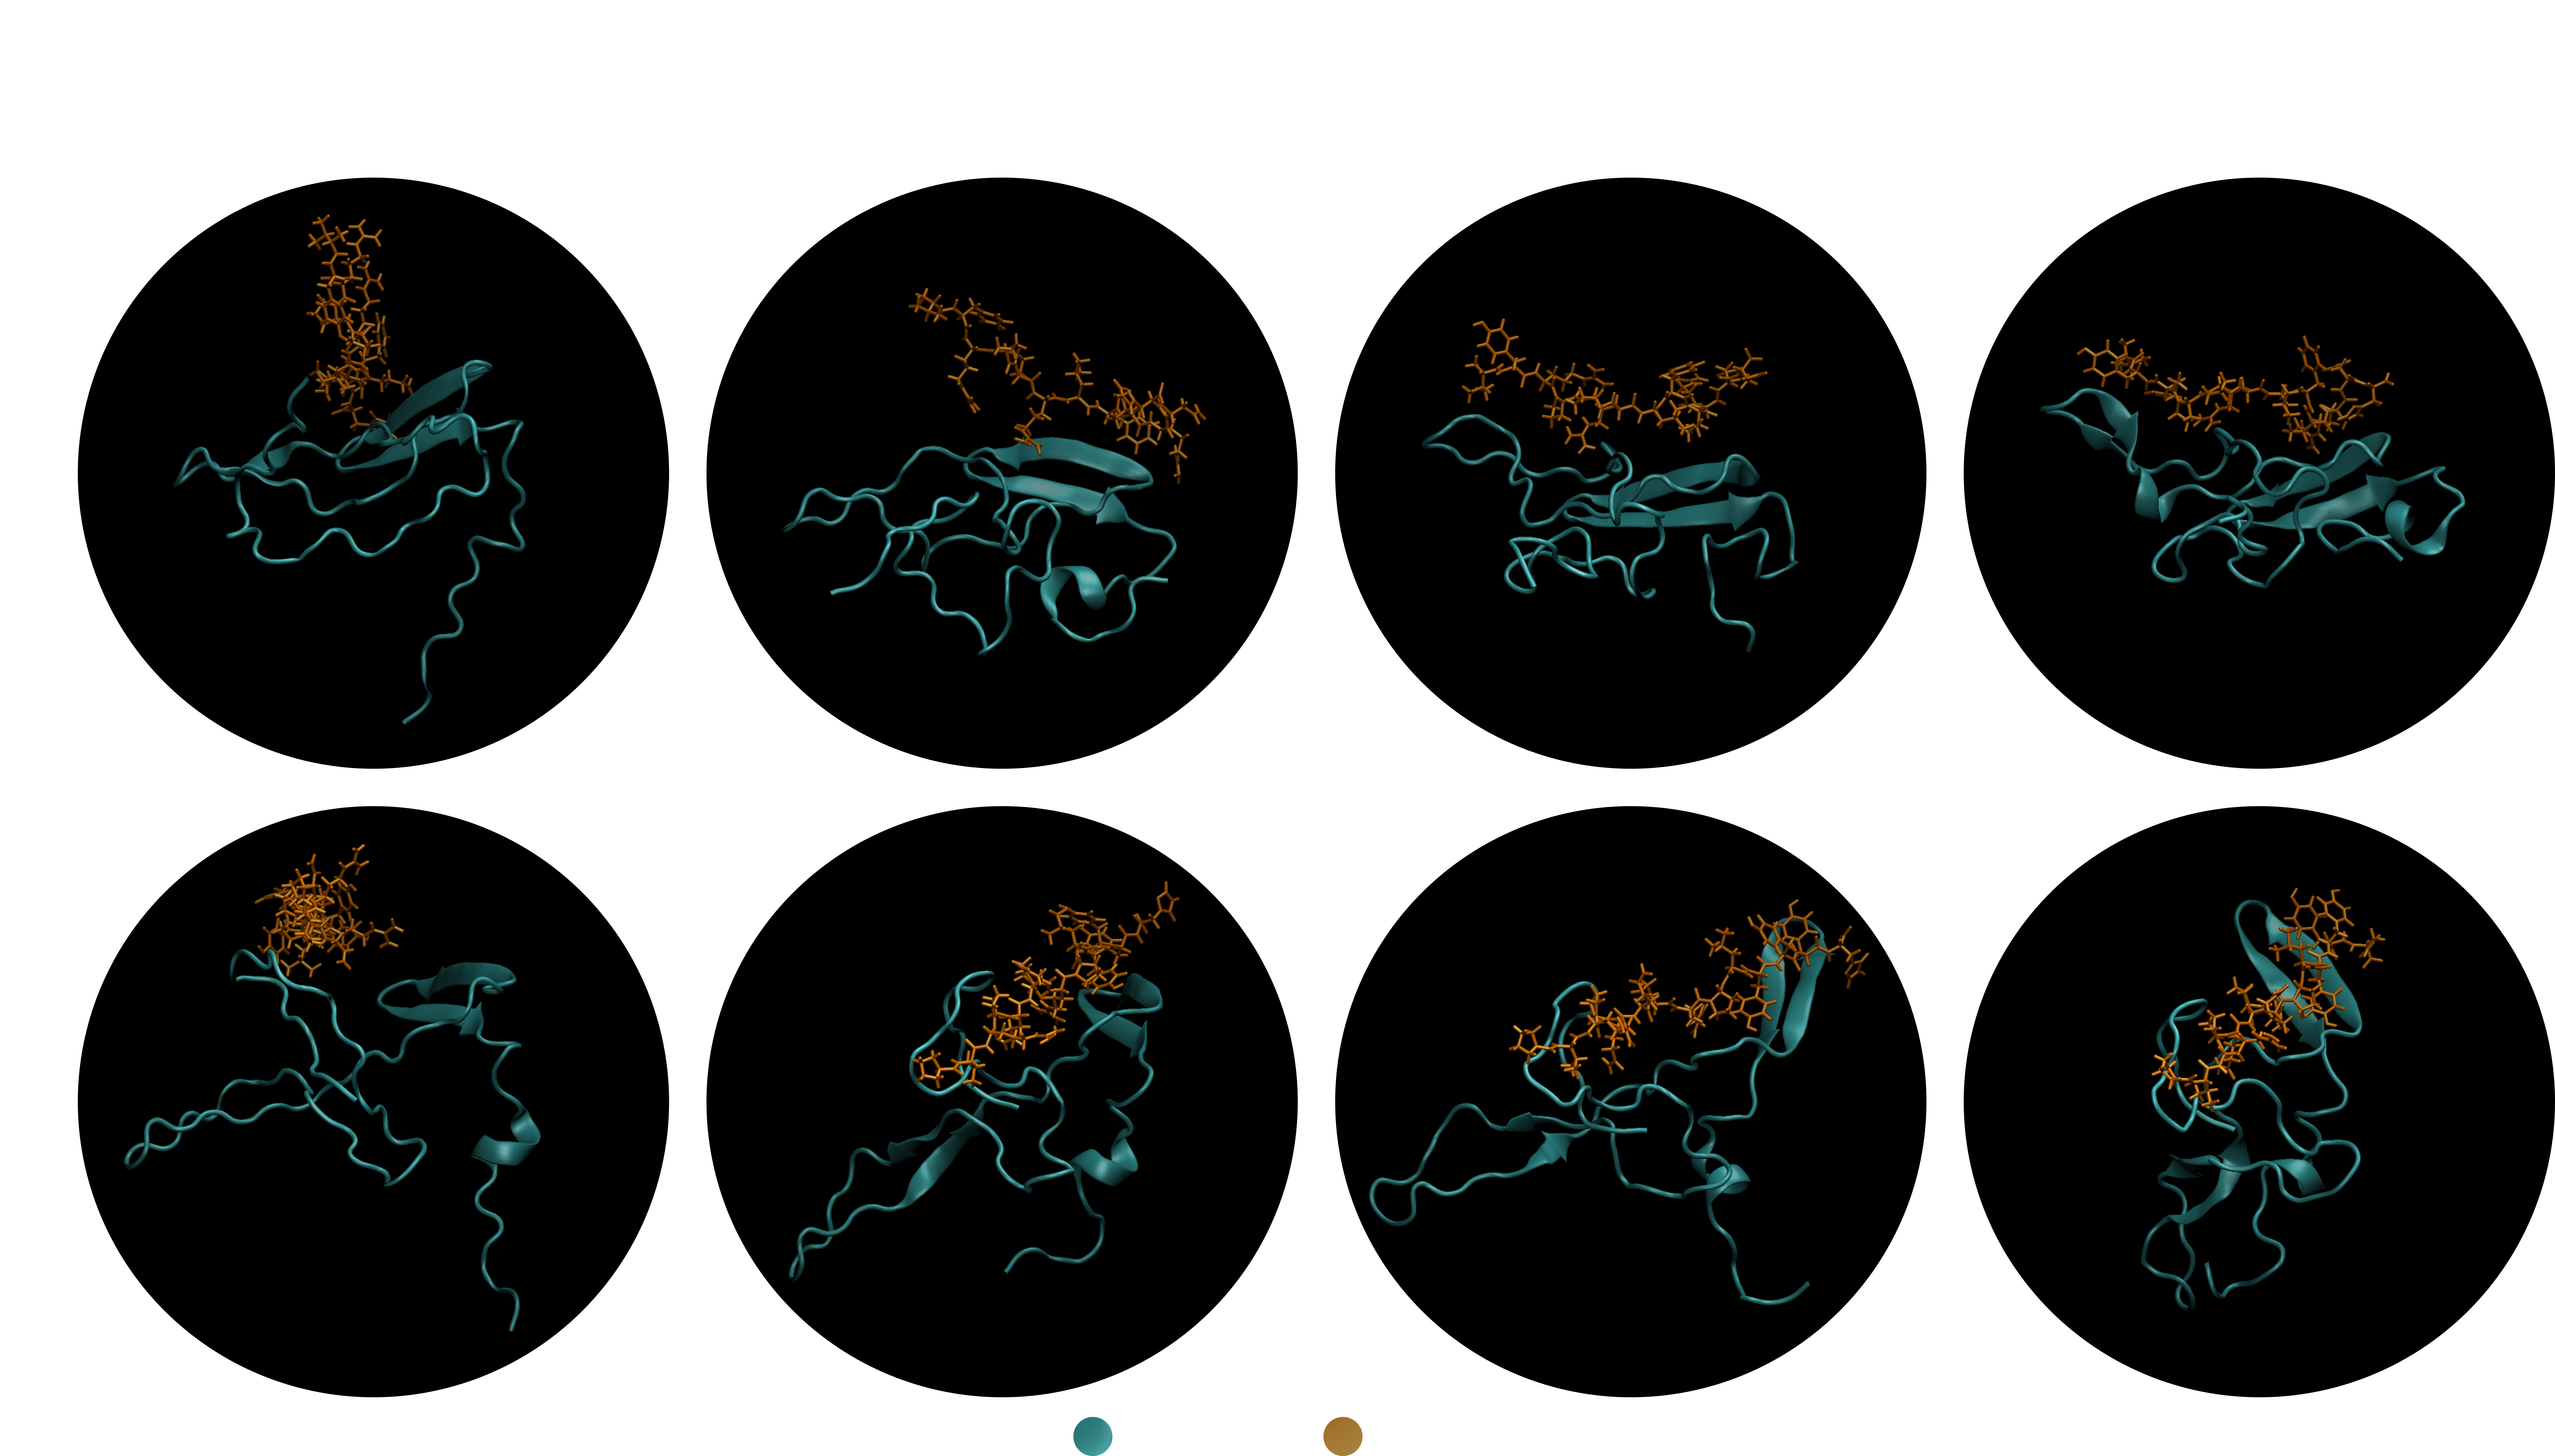

In [11]:
# ============================================================
# 11. Display receptor-aligned structural evolution
# ============================================================

from pathlib import Path
from IPython.display import Image, display

figure_2_path = (
    Path("..")
    / "figures"
    / "figure_2_receptor_aligned_structural_evolution.png"
)

if not figure_2_path.exists():
    raise FileNotFoundError(
        f"Figure not found: {figure_2_path.resolve()}"
    )

display(
    Image(
        filename=str(figure_2_path)
    )
)

## 12. Final quantitative MD comparison

The principal dynamic descriptors are summarized in the finalized quantitative MD figure below.

**Panel A** shows receptor-fitted peptide backbone RMSD throughout the 10 ns trajectories, with the 5–10 ns comparison window highlighted.

**Panel B** summarizes three complementary late-window interface descriptors:

- initial-contact retention,
- normalized receptor–peptide interface contacts,
- receptor–peptide centre-of-mass distance.

Together, these metrics distinguish preservation of the initial predicted pose from subsequent interface reorganization and overall receptor association.

Error bars represent **temporal standard deviation within each trajectory**. Individual MD frames are temporally correlated and are not independent simulation replicates.

In [12]:
# ============================================================
# 12. Display final quantitative MD comparison
# ============================================================

from pathlib import Path
from IPython.display import Image, display

figure_3_path = (
    Path("..")
    / "figures"
    / "figure_3_md_pose_and_interface_descriptors.png"
)

if not figure_3_path.exists():
    raise FileNotFoundError(
        f"Figure not found: {figure_3_path.resolve()}"
    )

display(
    Image(
        filename=str(figure_3_path)
    )
)

## 13. Interpretation, limitations and next steps

### Interpretation

The MD trajectories add complementary dynamic information to the static ColabFold-derived structural ranking.

`pep_006`, which received the higher Ly6a structure-aware score in Notebook 04, shows **lower receptor-fitted peptide RMSD** during the 5–10 ns comparison window:

- `pep_006`: **1.416 ± 0.092 nm**
- `pep_000`: **1.817 ± 0.076 nm**

This suggests that `pep_006` preserves its initial receptor-relative pose more closely during the present simulations.

However, the interface descriptors reveal a different aspect of the trajectories. `pep_000` retains a larger fraction of its initial contact network, develops a substantially denser receptor–peptide interface after normalization for peptide size, and maintains a smaller receptor–peptide centre-of-mass separation.

At the same time, the minimum heavy-atom distance is essentially identical between the systems, and normalized intermolecular hydrogen bonding is very similar.

Taken together, the simulations therefore do **not** identify a single universally superior complex. Instead, they distinguish different dynamic behaviours:

- `pep_006` shows greater preservation of its initial predicted receptor-relative pose,
- `pep_000` undergoes greater reorganization while forming a denser and spatially closer interface.

The MD layer should therefore be viewed as a complementary structural triage step rather than a simple validation of the preceding ColabFold ranking.

### Limitations

These results are preliminary and should be interpreted within several important constraints:

1. Only **one 10 ns trajectory per peptide** was performed. Temporal standard deviations describe fluctuations within individual trajectories and do not represent replicate-level uncertainty.

2. The starting receptor–peptide complexes originate from deliberately lightweight ColabFold screening and have relatively low interface confidence. The simulations therefore explore the behaviour of these starting hypotheses rather than validated binding poses.

3. The preliminary Ly6a construct does not reproduce the complete native disulfide topology. Substantial receptor backbone relaxation is consequently observed during the simulations.

4. Ly6a is simulated as an isolated extracellular-domain approximation rather than in its native membrane-associated environment. Surfaces that would normally be constrained by membrane orientation or GPI anchoring may therefore be artificially accessible to the peptide.

5. The present descriptors quantify structural persistence, interface organization and spatial association. They do **not** establish binding affinity, BBB transport, transcytosis, toxicity or therapeutic efficacy.

### Next steps

A more rigorous downstream workflow would use a common validated Ly6a receptor scaffold with appropriate disulfide connectivity and native orientation, followed by multiple starting poses, independent MD replicates and longer simulations.

Future peptide optimization could also treat the structural outputs as complementary objectives rather than collapsing them into a single descriptor. Candidate ranking could combine:

- predicted interface confidence,
- MD pose persistence,
- normalized interface-contact density,
- interface-contact persistence,
- receptor–peptide separation,
- peptide developability properties.

This would provide a natural basis for multi-objective or quality-diversity optimization in the later reward-guided design stage.